<a href="https://colab.research.google.com/github/marziqhaqkim-dotcom/ai_course_exercises/blob/main/ProjectGroup10ServiceAlert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1972779 entries, 0 to 1972778
Data columns (total 13 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   id                       int64         
 1   start                    datetime64[ns]
 2   end                      datetime64[ns]
 3   cause                    int64         
 4   description_text2        object        
 5   header_text2             object        
 6   route_id                 object        
 7   trip_id                  int64         
 8   schedule_relationship    int64         
 9   stop_id                  int64         
 10  date_inserted            datetime64[ns]
 11  date                     int64         
 12  alert_message_timestamp  object        
dtypes: datetime64[ns](3), int64(6), object(4)
memory usage: 195.7+ MB


In [2]:
df.shape

(1972779, 13)

In [7]:
from google.colab import drive
import re
import numpy as np
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')

# Define the full path to your parquet file in Drive
file_path = '/content/drive/My Drive/service_alerts_2024.parquet'

# 2. Load ONLY the required columns to save RAM during initial load
cols_to_load = [
    "cause",
    "header_text2",
    "description_text2",
    "start",
    "end",
    "alert_message_timestamp",
    "date",
    "route_id",
    "stop_id",
]
df = pd.read_parquet(file_path, columns=cols_to_load)

# 3. Vectorized string concatenation (handles missing NaNs gracefully)
full_text = (
    df["header_text2"].fillna("").astype(str)
    + " "
    + df["description_text2"].fillna("").astype(str)
).str.lower()

# 4. Rules mapping (Ordered list of tuples)
RULES = [
    (
        6,
        "ACCIDENT",
        r"\b(olycka|krock|påkörning|påkörd|urspårning|urspårad|kollision)\w*",
    ),
    (
        3,
        "TECHNICAL_PROBLEM",
        r"\b(signalfel|elfel|vagnfel|fordonsfel|strömlöst|banarbete|växelfel|spårfel|bromsfel|tekniskt)\w*",
    ),
    (
        7,
        "WEATHER",
        r"\b(väder|storm|snö|halka|snöfall|skyfall|översvämning|is|oväder)\w*",
    ),
    (
        8,
        "MAINTENANCE",
        r"\b(underhåll|reparation|spårarbete|vägarbete|underhållsarbete)\w*",
    ),
    (
        10,
        "CONGESTION",
        r"\b(kö|bilköer|trafikstockning|trängsel|tät\strafik)\w*",
    ),
    (4, "STRIKE", r"\b(strejk|arbetsnedläggelse|personalbrist)\w*"),
]

# 5. Initialize result arrays with defaults (Vectorized allocation)
# Default: 1 (UNKNOWN) for empty strings, 2 (OTHER) for non-matching text
is_empty = full_text.str.strip().eq("")
enum_arr = np.where(is_empty, 1, 2)
name_arr = np.where(is_empty, "UNKNOWN_CAUSE", "OTHER_CAUSE")
keyword_arr = np.full(len(df), None, dtype=object)

# 6. Apply regex extractions in a single vectorized pass per rule
for cause_enum, cause_name, pattern in RULES:
    # Find regex matches across the entire pandas Series at once
    matches_df = full_text.str.extract(f"({pattern})", expand=False)

    # Explicitly select the first column, as matches_df is a DataFrame with 2 columns
    # based on the kernel state, even with a single capturing group regex.
    matches_series = matches_df.iloc[:, 0]

    has_match = matches_series.notna() & (
        enum_arr == 2
    )  # match only if not previously matched

    enum_arr[has_match] = cause_enum
    name_arr[has_match] = cause_name
    keyword_arr[has_match] = matches_series[has_match]

# 7. Assign back to DataFrame directly (Zero duplicate memory overhead)
df["extracted_cause_enum"] = enum_arr
df["extracted_cause_name"] = name_arr
df["matched_keyword"] = keyword_arr

# 8. Vectorized Imputation
df["final_cause_enum"] = np.where(
    df["cause"].isin([1, 2]), df["extracted_cause_enum"], df["cause"]
)

# Display the first 10 rows after processing
display(df.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,cause,header_text2,description_text2,start,end,alert_message_timestamp,date,route_id,stop_id,extracted_cause_enum,extracted_cause_name,matched_keyword,final_cause_enum
0,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,2024-01-06 05:06:14,2024-01-06 05:08:13,None,20240106,-1,9022001001701003,2,OTHER_CAUSE,None,2
1,2,Ingen påstigning,Ingen påstigning,2024-01-06 05:06:47,2024-01-06 05:08:44,None,20240106,-1,9022001003481001,2,OTHER_CAUSE,None,2
2,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,2024-01-06 05:06:56,2024-01-06 05:08:55,None,20240106,-1,9022001001551001,2,OTHER_CAUSE,None,2
3,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,2024-01-06 05:07:09,2024-01-06 05:09:08,None,20240106,-1,9022001001831002,2,OTHER_CAUSE,None,2
4,2,Ingen påstigning,Ingen påstigning,2024-01-06 05:07:34,2024-01-06 05:09:34,None,20240106,-1,9022001002121002,2,OTHER_CAUSE,None,2
5,2,Ingen påstigning,Ingen påstigning,2024-01-06 05:07:24,2024-01-06 05:07:44,None,20240106,-1,9022001002601003,2,OTHER_CAUSE,None,2
6,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,2024-01-06 05:07:35,2024-01-06 05:09:35,None,20240106,-1,9022001001931002,2,OTHER_CAUSE,None,2
7,2,Ingen påstigning,Ingen påstigning,2024-01-06 05:08:40,2024-01-06 05:10:40,None,20240106,-1,9022001002111002,2,OTHER_CAUSE,None,2
8,2,Ingen påstigning,Ingen påstigning,2024-01-06 05:08:43,2024-01-06 05:10:43,None,20240106,-1,9022001002531001,2,OTHER_CAUSE,None,2
9,2,Se upp för passerande tåg,Se upp för passerande tåg,2024-01-06 05:09:26,2024-01-06 05:11:26,None,20240106,-1,9022001006781001,2,OTHER_CAUSE,None,2


In [18]:
import pandas as pd
import numpy as np
import re
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from google.colab import drive

# ----------------------------------------------------
# 1. LOAD DATA & CLEAN (LOW-RAM DTYPES)
# ----------------------------------------------------
# Mount Google Drive to access the file
drive.mount('/content/drive')

# Define the full path to your parquet file in Drive
file_path = '/content/drive/My Drive/service_alerts_2024.parquet'

# Load required columns only to save RAM during initial read
cols_to_use = [
    'id', 'start', 'end', 'cause', 'route_id', 'stop_id',
    'schedule_relationship', 'header_text2', 'description_text2',
    'date', 'alert_message_timestamp' # Added these two columns
]

df = pd.read_parquet(file_path, columns=cols_to_use)

# Convert timestamps and filter for 2024 records
df['start'] = pd.to_datetime(df['start'])
df['end'] = pd.to_datetime(df['end'])
# Convert the new date columns to datetime, coercing errors
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce') # Assuming YYYYMMDD format for int date
df['alert_message_timestamp'] = pd.to_datetime(df['alert_message_timestamp'], errors='coerce') # Assuming string timestamp

df_2024 = df[df['end'].dt.year == 2024].copy()
del df  # Free up raw df memory immediately

# ----------------------------------------------------
# 2. FEATURE ENGINEERING & CARDINALITY REDUCTION
# ----------------------------------------------------
# Numerical Features (using int16/float32 to save RAM)
df_2024['duration_minutes'] = ((df_2024['end'] - df_2024['start']).dt.total_seconds() / 60.0).astype(np.float32)
df_2024['start_hour'] = df_2024['start'].dt.hour.astype(np.int8)
df_2024['start_day_of_week'] = df_2024['start'].dt.dayofweek.astype(np.int8)
df_2024['is_weekend'] = (df_2024['start_day_of_week'] >= 5).astype(np.int8)

# Reduce Stop ID Cardinality: Keep top 100 most frequent stops, map rest to 'other'
top_stops = df_2024['stop_id'].value_counts().nlargest(100).index
df_2024['stop_id_clean'] = df_2024['stop_id'].where(df_2024['stop_id'].isin(top_stops), -1).astype(str)

top_routes = df_2024['route_id'].value_counts().nlargest(50).index
df_2024['route_id_clean'] = df_2024['route_id'].where(df_2024['route_id'].isin(top_routes), '-1').astype(str)

# ----------------------------------------------------
# 3. SPARSE ENCODING & VECTORIZATION (LIGHTWEIGHT)
# ----------------------------------------------------
# A. One-Hot Encoding (SPARSE = TRUE saves gigabytes of RAM)
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore', dtype=np.float32)
X_cat_sparse = ohe.fit_transform(df_2024[['route_id_clean', 'stop_id_clean', 'schedule_relationship']])

# B. Scaled Numeric Features (Convert to sparse)
scaler = StandardScaler()
X_num_dense = scaler.fit_transform(df_2024[['start_hour', 'start_day_of_week', 'is_weekend', 'duration_minutes']]).astype(np.float32)
from scipy.sparse import csr_matrix
X_num_sparse = csr_matrix(X_num_dense)

# C. TF-IDF Text Feature Extraction (Lecture 4)
df_2024['full_text'] = (df_2024['header_text2'].fillna('') + ' ' + df_2024['description_text2'].fillna('')).str.lower()
df_2024['clean_text'] = df_2024['full_text'].apply(lambda t: re.sub(r'[^\x00-\x7F]', '', t)) # fix for bad characters that were failing

swedish_stop_words = ['och', 'i', 'att', 'på', 'med', 'för', 'av', 'till', 'som', 'är', 'ett', 'en', 'det', 'har']
tfidf = TfidfVectorizer(stop_words=swedish_stop_words, ngram_range=(1, 2), min_df=50, max_features=150, dtype=np.float32)
X_text_sparse = tfidf.fit_transform(df_2024['clean_text'])

# ----------------------------------------------------
# 4. STACK INTO SPARSE FEATURE MATRIX (X)
# ----------------------------------------------------
# Stacking sparse matrices uses negligible RAM (~150 MB instead of 39 GB!)
X_sparse = hstack([X_num_sparse, X_cat_sparse, X_text_sparse]).tocsr()
y_cause = df_2024['cause'].values

print(f"Dataset built successfully!")
print(f"Sparse Matrix Shape: {X_sparse.shape}")
print(f"RAM Usage for Matrix X: ~{X_sparse.data.nbytes / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset built successfully!
Sparse Matrix Shape: (1971329, 306)
RAM Usage for Matrix X: ~163.61 MB


In [11]:
# Extract the month from the 'start' column
df_2024 = df_2024.copy()
df_2024['start_month'] = df_2024['start'].dt.to_period('M')
# Count the number of alerts per month
alerts_per_month = df_2024['start_month'].value_counts().sort_index()
# Display the results
display(alerts_per_month)

,count
start_month,
2023-12,8
2024-01,203171
2024-02,168005
2024-03,156737
2024-04,161792
2024-05,196592
2024-06,156395
2024-07,106808
2024-08,150971


In [12]:
selected_columns = df_2024[['id', 'start', 'end', 'route_id', 'stop_id', 'full_text', 'clean_text']]
display(selected_columns.head())

,id,start,end,route_id,stop_id,full_text,clean_text
0,14050001656394124,2024-01-06 05:06:14,2024-01-06 05:08:13,-1,9022001001701003,ingen pã¥stigning ingen pã¥stigning,ingen pstigning ingen pstigning
1,14050001656394176,2024-01-06 05:06:47,2024-01-06 05:08:44,-1,9022001003481001,ingen påstigning ingen påstigning,ingen pstigning ingen pstigning
2,14050001656394207,2024-01-06 05:06:56,2024-01-06 05:08:55,-1,9022001001551001,ingen pã¥stigning ingen pã¥stigning,ingen pstigning ingen pstigning
3,14050001656394246,2024-01-06 05:07:09,2024-01-06 05:09:08,-1,9022001001831002,ingen pã¥stigning ingen pã¥stigning,ingen pstigning ingen pstigning
4,14050001656394262,2024-01-06 05:07:34,2024-01-06 05:09:34,-1,9022001002121002,ingen påstigning ingen påstigning,ingen pstigning ingen pstigning


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [17]:
import numpy as np

# Re-apply the cause extraction logic to df_2024
# RULES variable is assumed to be available from previous executions.

# 5. Initialize result arrays with defaults
full_text_df2024 = df_2024['full_text'] # Use full_text from df_2024
is_empty_df2024 = full_text_df2024.str.strip().eq("")
enum_arr_df2024 = np.where(is_empty_df2024, 1, 2)
name_arr_df2024 = np.where(is_empty_df2024, "UNKNOWN_CAUSE", "OTHER_CAUSE")
keyword_arr_df2024 = np.full(len(df_2024), None, dtype=object)

# 6. Apply regex extractions in a single vectorized pass per rule
for cause_enum, cause_name, pattern in RULES:
    matches_df = full_text_df2024.str.extract(f"({pattern})", expand=False)

    # Explicitly select the first column
    matches_series = matches_df.iloc[:, 0]

    has_match = matches_series.notna() & (
        enum_arr_df2024 == 2
    )  # match only if not previously matched

    enum_arr_df2024[has_match] = cause_enum
    name_arr_df2024[has_match] = cause_name
    keyword_arr_df2024[has_match] = matches_series[has_match]

# 7. Assign back to df_2024
df_2024["extracted_cause_enum"] = enum_arr_df2024
df_2024["extracted_cause_name"] = name_arr_df2024

# Now, group by start_month and extracted_cause_name and count unique alerts
alerts_by_month_cause = df_2024.groupby(['start_month', 'extracted_cause_name'])['id'].nunique().reset_index()
alerts_by_month_cause.rename(columns={'id': 'alert_count'}, inplace=True)

# Display the aggregated data
display(alerts_by_month_cause)

,start_month,extracted_cause_name,alert_count
0,2023-12,OTHER_CAUSE,8
1,2024-01,ACCIDENT,40
2,2024-01,CONGESTION,946
3,2024-01,MAINTENANCE,59
4,2024-01,OTHER_CAUSE,67975
...,...,...,...
80,2024-12,MAINTENANCE,124
81,2024-12,OTHER_CAUSE,61715
82,2024-12,STRIKE,225
83,2024-12,TECHNICAL_PRO,3875


### Monthly Cause of Delay Aggregation

Here is the aggregated view of alerts by month and their extracted causes:

In [20]:
# Display the aggregated data as previously calculated
display(alerts_by_month_cause)

,start_month,extracted_cause_name,alert_count
0,2023-12,OTHER_CAUSE,8
1,2024-01,ACCIDENT,40
2,2024-01,CONGESTION,946
3,2024-01,MAINTENANCE,59
4,2024-01,OTHER_CAUSE,67975
...,...,...,...
80,2024-12,MAINTENANCE,124
81,2024-12,OTHER_CAUSE,61715
82,2024-12,STRIKE,225
83,2024-12,TECHNICAL_PRO,3875


### Individual Alert Details for a Specific Month and Cause

To view the individual alerts with `id`, `start`, `end`, `route_id`, `stop_id`, `full_text`, and `clean_text` for a particular month and cause, you can filter `df_2024`. Below is an example showing all alerts categorized as 'ACCIDENT' in '2024-01'.

In [23]:
# Re-create 'start_month' if it's missing (ensuring context)
df_2024['start_month'] = df_2024['start'].dt.to_period('M')

# --- Re-apply cause extraction to df_2024 to ensure 'extracted_cause_name' exists ---
# RULES variable is assumed to be available from previous executions.

# Initialize result arrays with defaults
full_text_df2024 = df_2024['full_text'] # Use full_text from df_2024
is_empty_df2024 = full_text_df2024.str.strip().eq("")
enum_arr_df2024 = np.where(is_empty_df2024, 1, 2)
name_arr_df2024 = np.where(is_empty_df2024, "UNKNOWN_CAUSE", "OTHER_CAUSE")
keyword_arr_df2024 = np.full(len(df_2024), None, dtype=object)

# Apply regex extractions in a single vectorized pass per rule
for cause_enum, cause_name, pattern in RULES:
    matches_df = full_text_df2024.str.extract(f"({pattern})", expand=False)

    # Explicitly select the first column
    matches_series = matches_df.iloc[:, 0]

    has_match = matches_series.notna() & (
        enum_arr_df2024 == 2
    )  # match only if not previously matched

    enum_arr_df2024[has_match] = cause_enum
    name_arr_df2024[has_match] = cause_name
    keyword_arr_df2024[has_match] = matches_series[has_match]

# Assign back to df_2024
df_2024["extracted_cause_enum"] = enum_arr_df2024
df_2024["extracted_cause_name"] = name_arr_df2024
# ----------------------------------------------------------------------------------

# Example: Filter for 'ACCIDENT' in '2024-01'
selected_month = pd.Period('2024-01', freq='M')
selected_cause = 'ACCIDENT'

filtered_alerts = df_2024[
    (df_2024['start_month'] == selected_month) &
    (df_2024['extracted_cause_name'] == selected_cause)
]

display(filtered_alerts[['id', 'start', 'end', 'route_id', 'stop_id', 'full_text', 'clean_text']].head())

,id,start,end,route_id,stop_id,full_text,clean_text
20747,14050001655617300,2024-01-04 11:42:00,2024-01-04 11:58:00,-1,-1,slussen kl 11:17 till styrmannen är inställd p...,slussen kl 11:17 till styrmannen r instlld pga...
20807,14050001655622633,2024-01-04 12:07:56,2024-01-04 13:03:00,-1,-1,styrmannen kl 11:49 till slussen är inställd p...,styrmannen kl 11:49 till slussen r instlld pga...
46033,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001012506000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46035,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050195000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46036,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050156000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."


In [25]:
import pandas as pd
import re
import ftfy
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# Define the full path to your parquet file in Drive
file_path = '/content/drive/My Drive/service_alerts_2024.parquet'

# 2. Load Data from the correct path
df = pd.read_parquet(file_path)

# 3. Clean Text Encoding (Fix 'pã¥stigning' -> 'påstigning')
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Repair mojibake and convert to lowercase
    fixed = ftfy.fix_text(text)
    return fixed.lower()

# Ensure text column exists and clean it
# Use 'full_text' from df if available, otherwise 'description_text2' or 'header_text2'
if 'full_text' in df.columns:
    source_col = 'full_text'
elif 'description_text2' in df.columns and 'header_text2' in df.columns:
    # If full_text isn't pre-computed, create it from header and description
    df['full_text'] = (df['header_text2'].fillna('') + ' ' + df['description_text2'].fillna('')).str.lower()
    source_col = 'full_text'
elif 'clean_text' in df.columns: # Fallback if full_text is not directly available but clean_text is
    source_col = 'clean_text'
else:
    # Handle cases where expected text columns are missing or create a dummy column
    print("Warning: 'full_text', 'header_text2', or 'description_text2' not found. Creating empty 'text_clean'.")
    df['text_clean'] = ""
    source_col = 'text_clean'

df['text_clean'] = df[source_col].apply(clean_text)

# 4. Define Keyword Patterns
CATEGORIES = {
    'Collision & Accidents': r'kollision|olycka|påkörning|krock',
    'Technical & Vehicle Defect': r'fordonsfel|tågfel|bussfel|vagnfel|motorfel|tekniskt fel|dörrfel',
    'Track & Infrastructure': r'spårfel|signal-?fel|växelfel|elavbrott|strömlöst|kontaktledning',
    'Weather & Environmental': r'snö|halka|oväder|storm|skyfall|översvämning|träd',
    'Police & Medical': r'polis|sjukdom|sjukdomsfall|ordningsvakt|obehöriga|spårspring',
    'No Boarding / Canceled Stop': r'ingen p[åa]stigning|indragen hållplats|stannar inte vid'
}

# 5. Classification Function
def classify_alert(text):
    for category, pattern in CATEGORIES.items():
        if re.search(pattern, text):
            return category
    return 'Other / General Delay'

df['cause_category'] = df['text_clean'].apply(classify_alert)

# 6. Group Monthly
# Ensure start date is in datetime format
df['start'] = pd.to_datetime(df['start'])
df['year_month'] = df['start'].dt.to_period('M')

# Create monthly pivot table showing cause counts per month
monthly_causes = df.groupby(['year_month', 'cause_category']).size().unstack(fill_value=0)

# Display Monthly Summary
print("--- Monthly Incidents Summary ---")
print(monthly_causes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Monthly Incidents Summary ---
cause_category  Collision & Accidents  No Boarding / Canceled Stop  \
year_month                                                           
2023-12                             0                            0   
2024-01                           291                        13785   
2024-02                           364                        12655   
2024-03                           738                        12347   
2024-04                           317                        14233   
2024-05                           192                        15540   
2024-06                           221                        12280   
2024-07                            60                         8493   
2024-08                           238                        11855   
2024-09                           385                        13483 

### Exploring Individual Incidents by Month and Cause

The "Monthly Incidents Summary" provides a high-level overview of alert counts by category for each month. To view the detailed information (including `id`, `start`, `end`, `route_id`, `stop_id`, and text descriptions) for individual alerts within a specific month and cause category, you can filter the `df_2024` DataFrame.

Use the cell below to select a `target_month` and `target_cause`. The code will then display the detailed records for all alerts matching your criteria.

In [26]:
# Ensure 'start_month' and 'extracted_cause_name' are available in df_2024
# This logic is included here for self-containment, assuming df_2024 exists from previous cells.

# Re-create 'start_month' if it's missing (ensuring context)
# df_2024 is available from previous cells like 'zc1UKjiQpYjT'
df_2024['start_month'] = df_2024['start'].dt.to_period('M')

# --- Re-apply cause extraction to df_2024 to ensure 'extracted_cause_name' exists ---
# This block re-runs the categorization logic if df_2024 was generated without these columns
# RULES variable is assumed to be available from previous executions (e.g., FiW7CJS_o5ER).

# Initialize result arrays with defaults
# Check if 'full_text' exists, if not, create it from header_text2 and description_text2
if 'full_text' not in df_2024.columns:
    df_2024['full_text'] = (df_2024['header_text2'].fillna('') + ' ' + df_2024['description_text2'].fillna('')).str.lower()

full_text_df2024 = df_2024['full_text']
is_empty_df2024 = full_text_df2024.str.strip().eq("")
enum_arr_df2024 = np.where(is_empty_df2024, 1, 2)
name_arr_df2024 = np.where(is_empty_df2024, "UNKNOWN_CAUSE", "OTHER_CAUSE")
keyword_arr_df2024 = np.full(len(df_2024), None, dtype=object)

# Apply regex extractions in a single vectorized pass per rule
for cause_enum, cause_name, pattern in RULES:
    matches_df = full_text_df2024.str.extract(f"({pattern})", expand=False)

    # Explicitly select the first column
    matches_series = matches_df.iloc[:, 0]

    has_match = matches_series.notna() & (
        enum_arr_df2024 == 2
    )  # match only if not previously matched

    enum_arr_df2024[has_match] = cause_enum
    name_arr_df2024[has_match] = cause_name
    keyword_arr_df2024[has_match] = matches_series[has_match]

# Assign back to df_2024
df_2024["extracted_cause_enum"] = enum_arr_df2024
df_2024["extracted_cause_name"] = name_arr_df2024
# ----------------------------------------------------------------------------------

# --- Select a specific month and cause to view detailed alerts ---
# You can change these values to explore different subsets of your data
target_month = pd.Period('2024-01', freq='M') # Example: January 2024
target_cause = 'ACCIDENT'               # Example: 'ACCIDENT'

print(f"Displaying detailed alerts for {target_cause} in {target_month}:")

filtered_detailed_alerts = df_2024[
    (df_2024['start_month'] == target_month) &
    (df_2024['extracted_cause_name'] == target_cause)
]

# Display the requested columns for the filtered alerts
display(filtered_detailed_alerts[['id', 'start', 'end', 'route_id', 'stop_id', 'full_text', 'clean_text']].head(10))

print(f"\nTotal {len(filtered_detailed_alerts)} matching alerts found.")

Displaying detailed alerts for ACCIDENT in 2024-01:


,id,start,end,route_id,stop_id,full_text,clean_text
20747,14050001655617300,2024-01-04 11:42:00,2024-01-04 11:58:00,-1,-1,slussen kl 11:17 till styrmannen är inställd p...,slussen kl 11:17 till styrmannen r instlld pga...
20807,14050001655622633,2024-01-04 12:07:56,2024-01-04 13:03:00,-1,-1,styrmannen kl 11:49 till slussen är inställd p...,styrmannen kl 11:49 till slussen r instlld pga...
46033,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001012506000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46035,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050195000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46036,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050156000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46037,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050158000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46038,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050146000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46039,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050148000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46041,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050160000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."
46042,14050001657354887,2024-01-08 18:17:10,2024-01-08 19:16:00,9011001051300000,9021001050150000,"buss linje 513 stannar inte vid solna centrum,...","buss linje 513 stannar inte vid solna centrum,..."



Total 295 matching alerts found.


### Trend of Incident Counts Over Time

Let's visualize the total number of alerts per month to see the overall trend throughout the year.

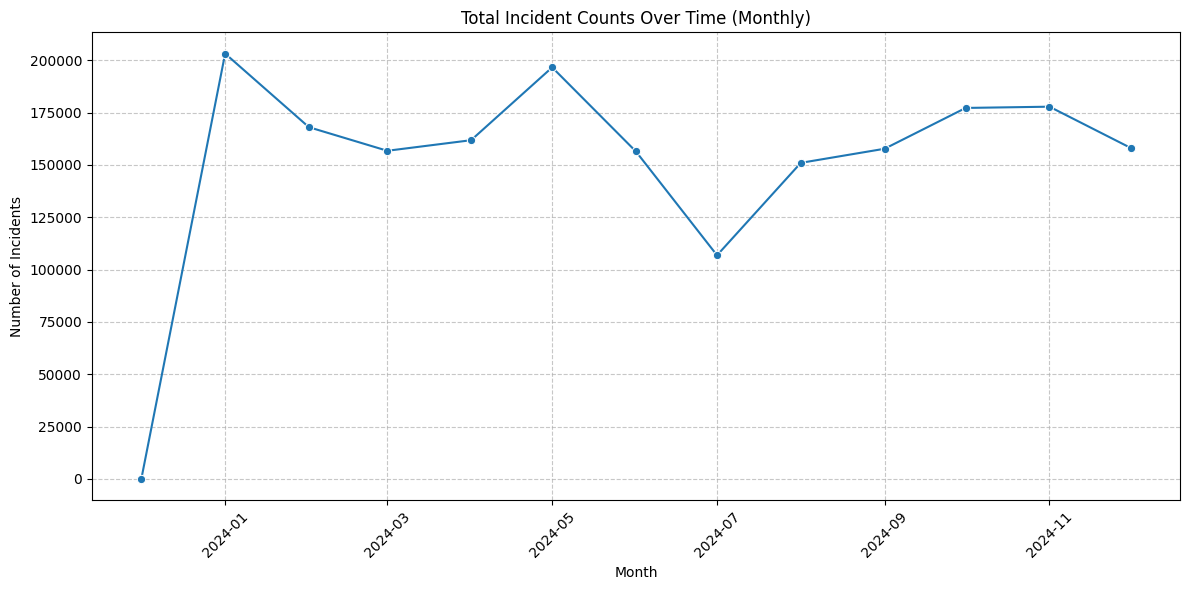

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure alerts_per_month is a DataFrame for plotting, with month as a column
# It's currently a Series with PeriodIndex, so we reset the index.
alerts_per_month_df = alerts_per_month.reset_index()
alerts_per_month_df.columns = ['month', 'count']

# Convert 'month' to datetime for better plotting on x-axis
alerts_per_month_df['month'] = alerts_per_month_df['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='count', data=alerts_per_month_df, marker='o')

plt.title('Total Incident Counts Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Top 5 Most Frequent Incident Routes

Let's identify and visualize the routes that experience the highest number of incidents.

In [29]:
most_frequent_route_id = top_5_routes.index[0]

# Filter df_2024 for the most frequent route
filtered_by_route = df_2024[df_2024['route_id_clean'] == most_frequent_route_id].copy()

# Count the causes for this route
causes_for_most_frequent_route = filtered_by_route['extracted_cause_name'].value_counts().reset_index()
causes_for_most_frequent_route.columns = ['Cause Category', 'Number of Incidents']

print(f"Analyzing common causes for the most frequent route: {most_frequent_route_id}")
display(causes_for_most_frequent_route)


Analyzing common causes for the most frequent route: -1


,Cause Category,Number of Incidents
0,OTHER_CAUSE,1679736
1,TECHNICAL_PRO,200857
2,CONGESTION,31216
3,WEATHER,13747
4,STRIKE,9928
5,MAINTENANCE,9705
6,ACCIDENT,2153
